In [2]:
### Importing Packages ###
import numpy as np
import pandas as pd
import csv
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import scipy.stats as stats
import geopandas as gpd
from shapely.geometry import Point, LineString
from shapely.ops import unary_union, nearest_points
import fiona as fiona 
import os
from PyEMD import EEMD 

In [11]:
## Reading in IMF Data to be used for Creating the EEMD Plots ##

#Defining the Coasts that are used in file paths#
coasts = ['Fl_to_NC', "Alabama_Missi", "Texas_lou", "VA_ME"]
Path = "/Users/epalmer/Meteorology-Research-Dr.-Misra-/Data/IMFs/ethan/"
imfs = [f'imf{i}' for i in range(1,11)]

## Reading in the Data ##
all_imfs_list = [] #Creating an empty list to hold every IMF dataframe for each coast
for coast in coasts: #For loop to go through each coast
    for imf in imfs: # Nested for loop to go through each IMF in the imfs list
        df = pd.read_csv(f'{Path}{imf}_{coast}.txt', header=None, names=['value']) # Reading in the IMF data into a dataframe
        df['coast'] = coast # Adding a column in the dataframe for each coast to easily identify which IMF belongs to each coast
        df['imf'] = imf # Adding a column in the dataframe to easily identify which IMF the values belong to
        df['year'] = np.arange(1851, 2025)
        all_imfs_list.append(df) #appending each IMF dataframe to the all_imfs_list list
all_imfs_df = pd.concat(all_imfs_list, ignore_index=True)  #concatenating all the dataframes into one MASSIVE dataframe to be used for later analysis

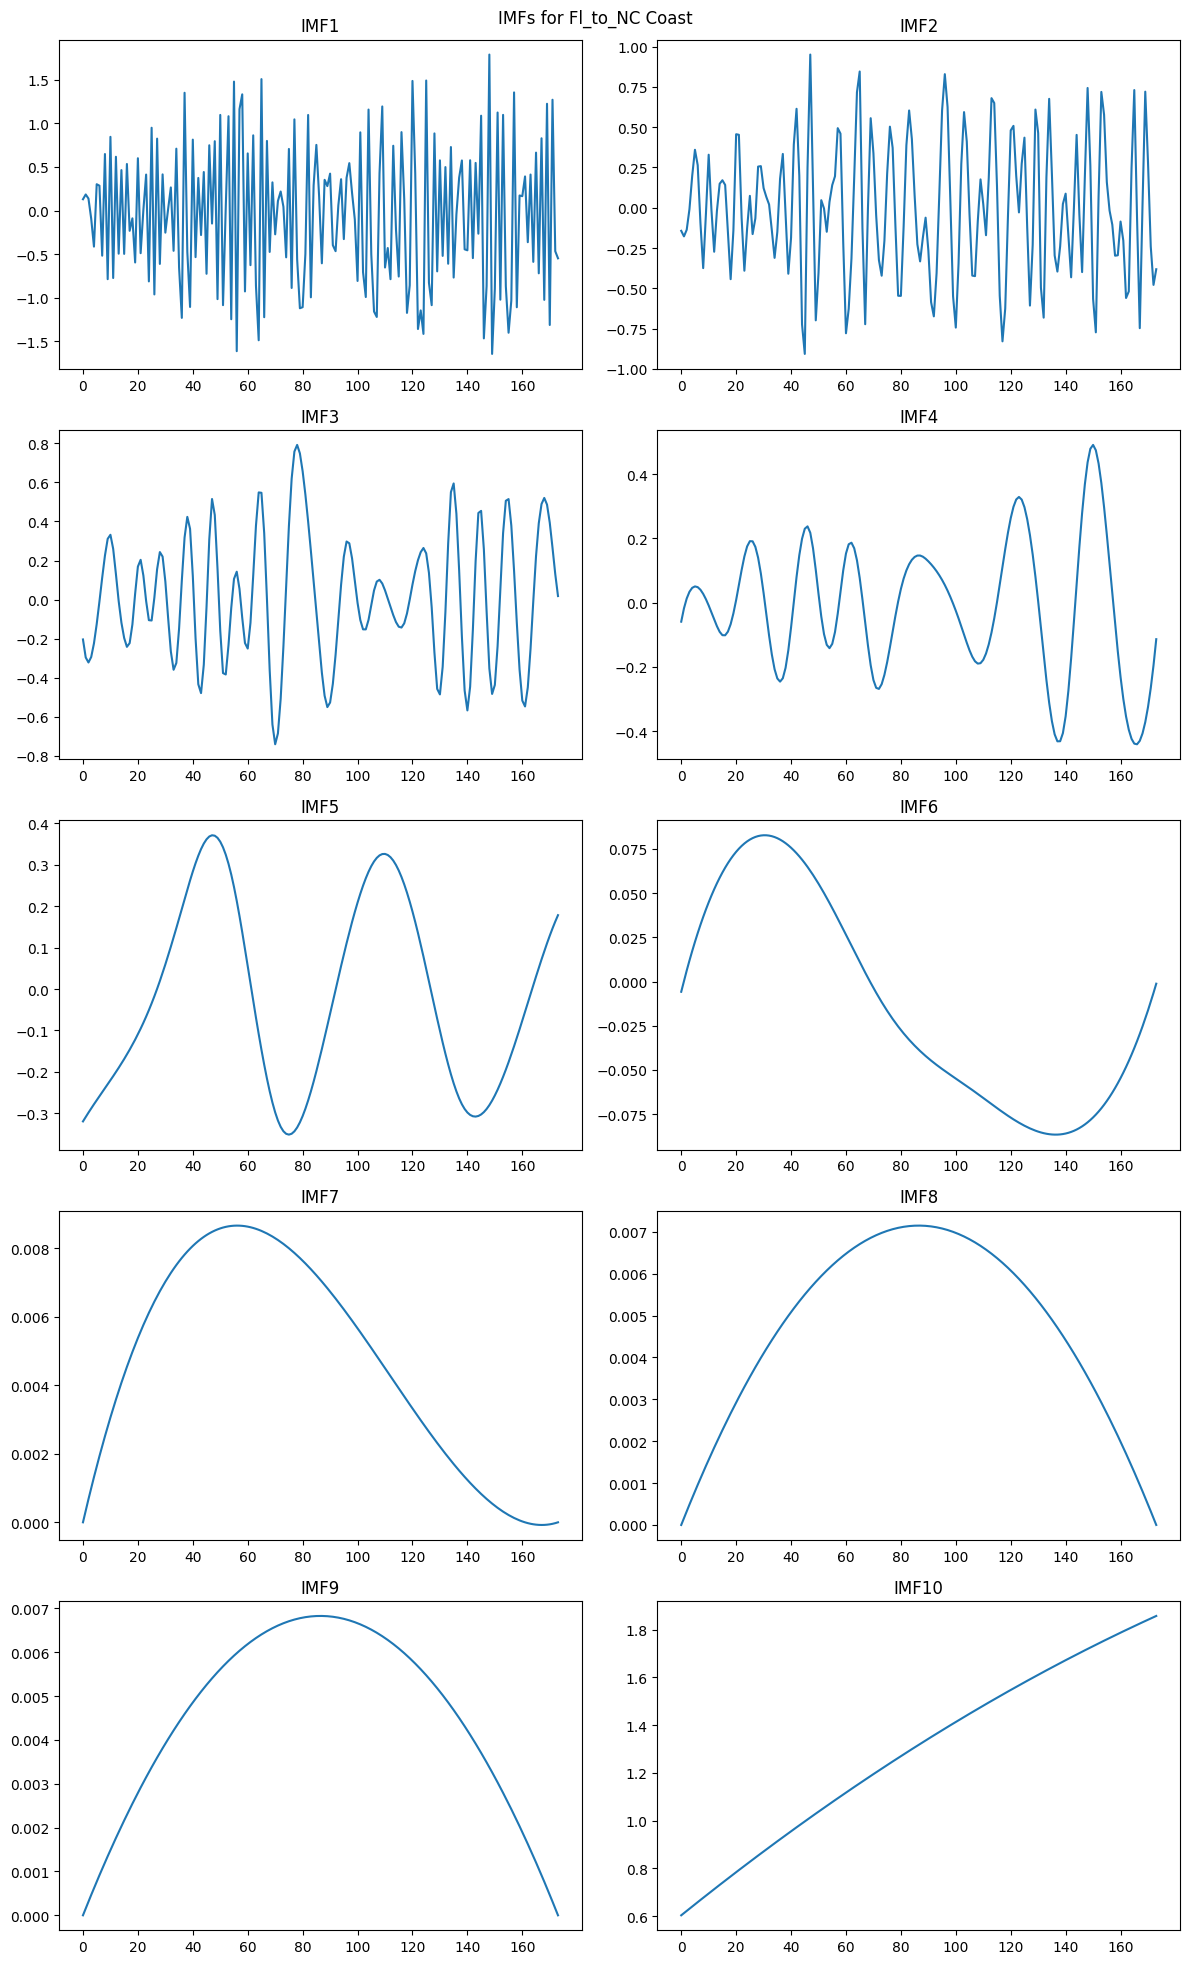

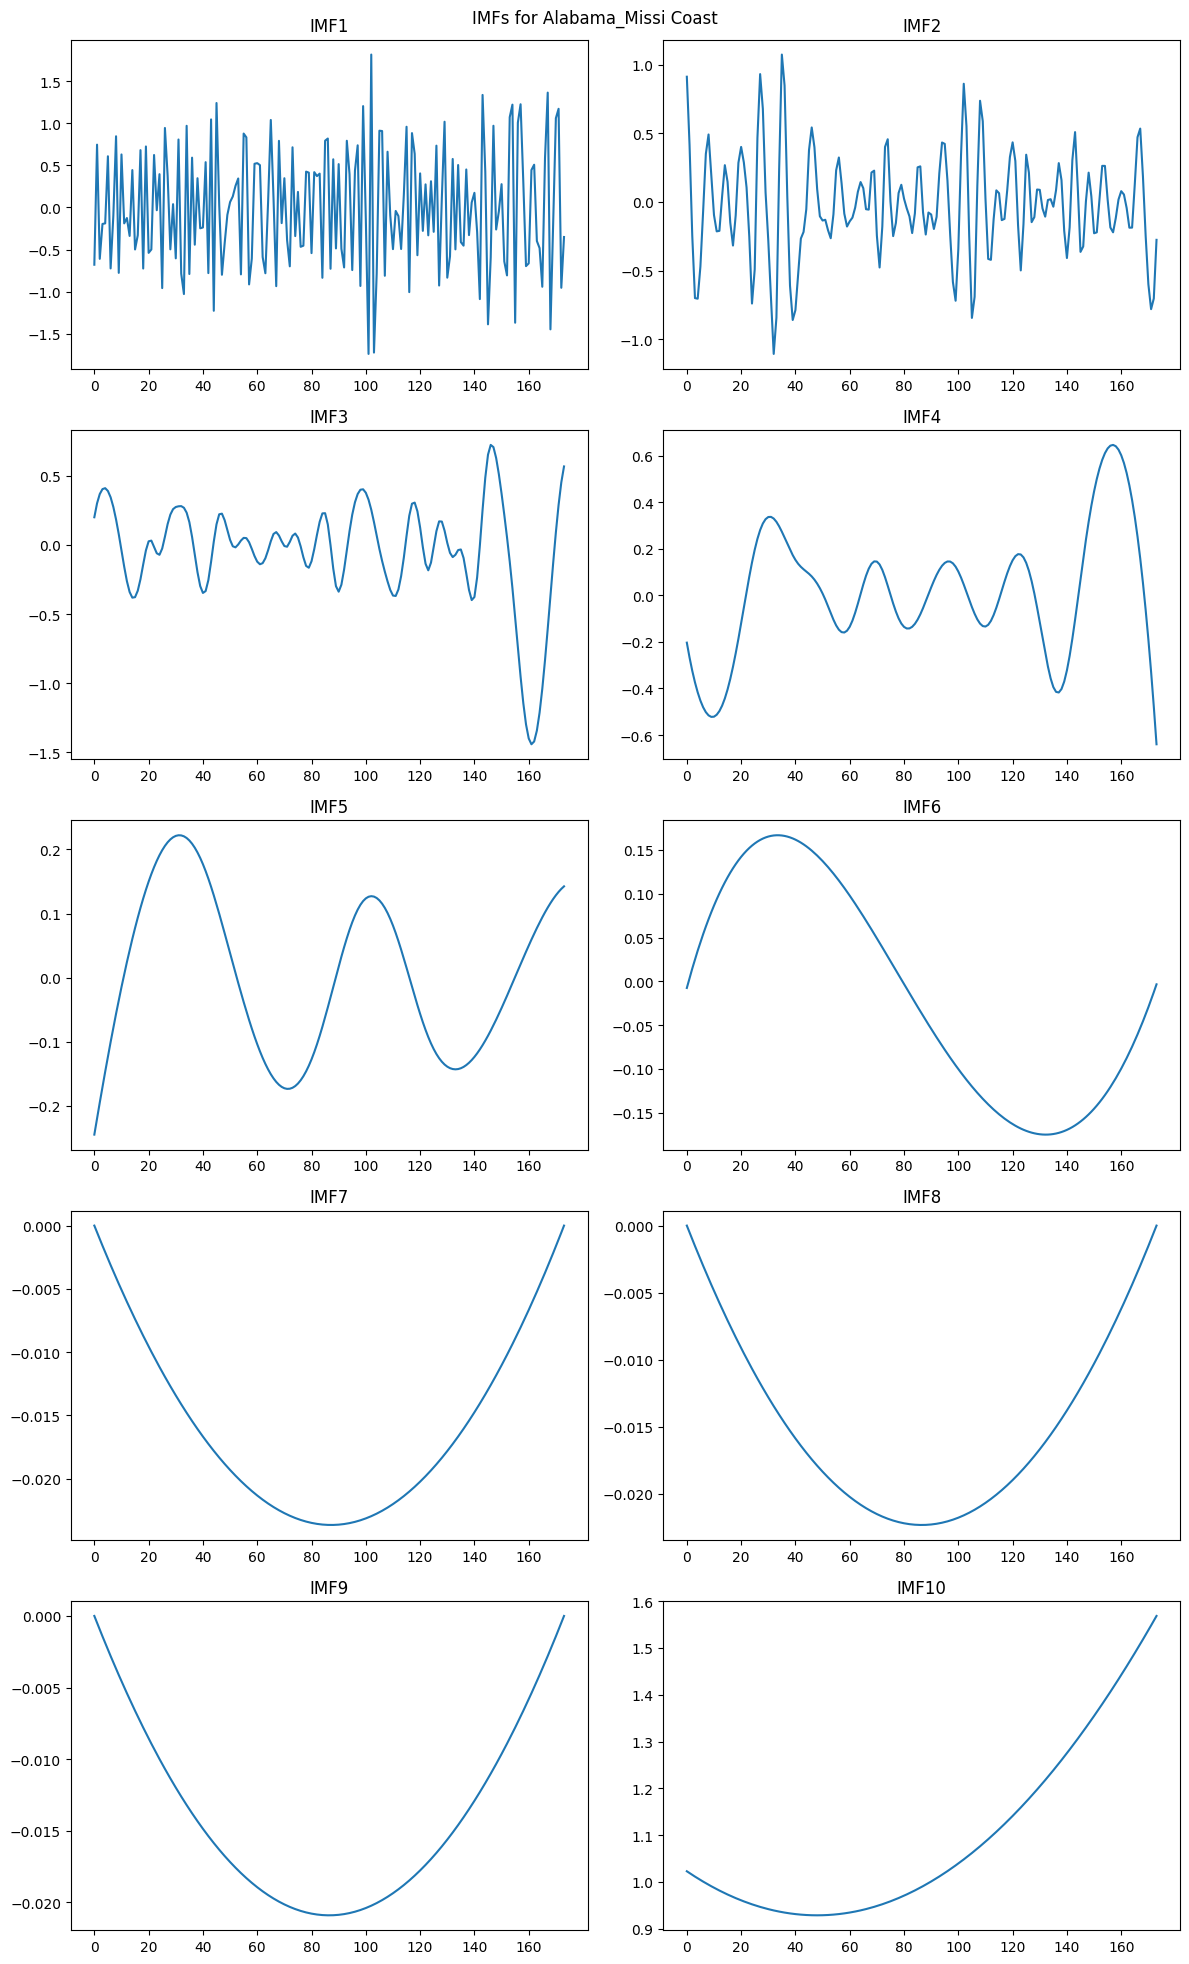

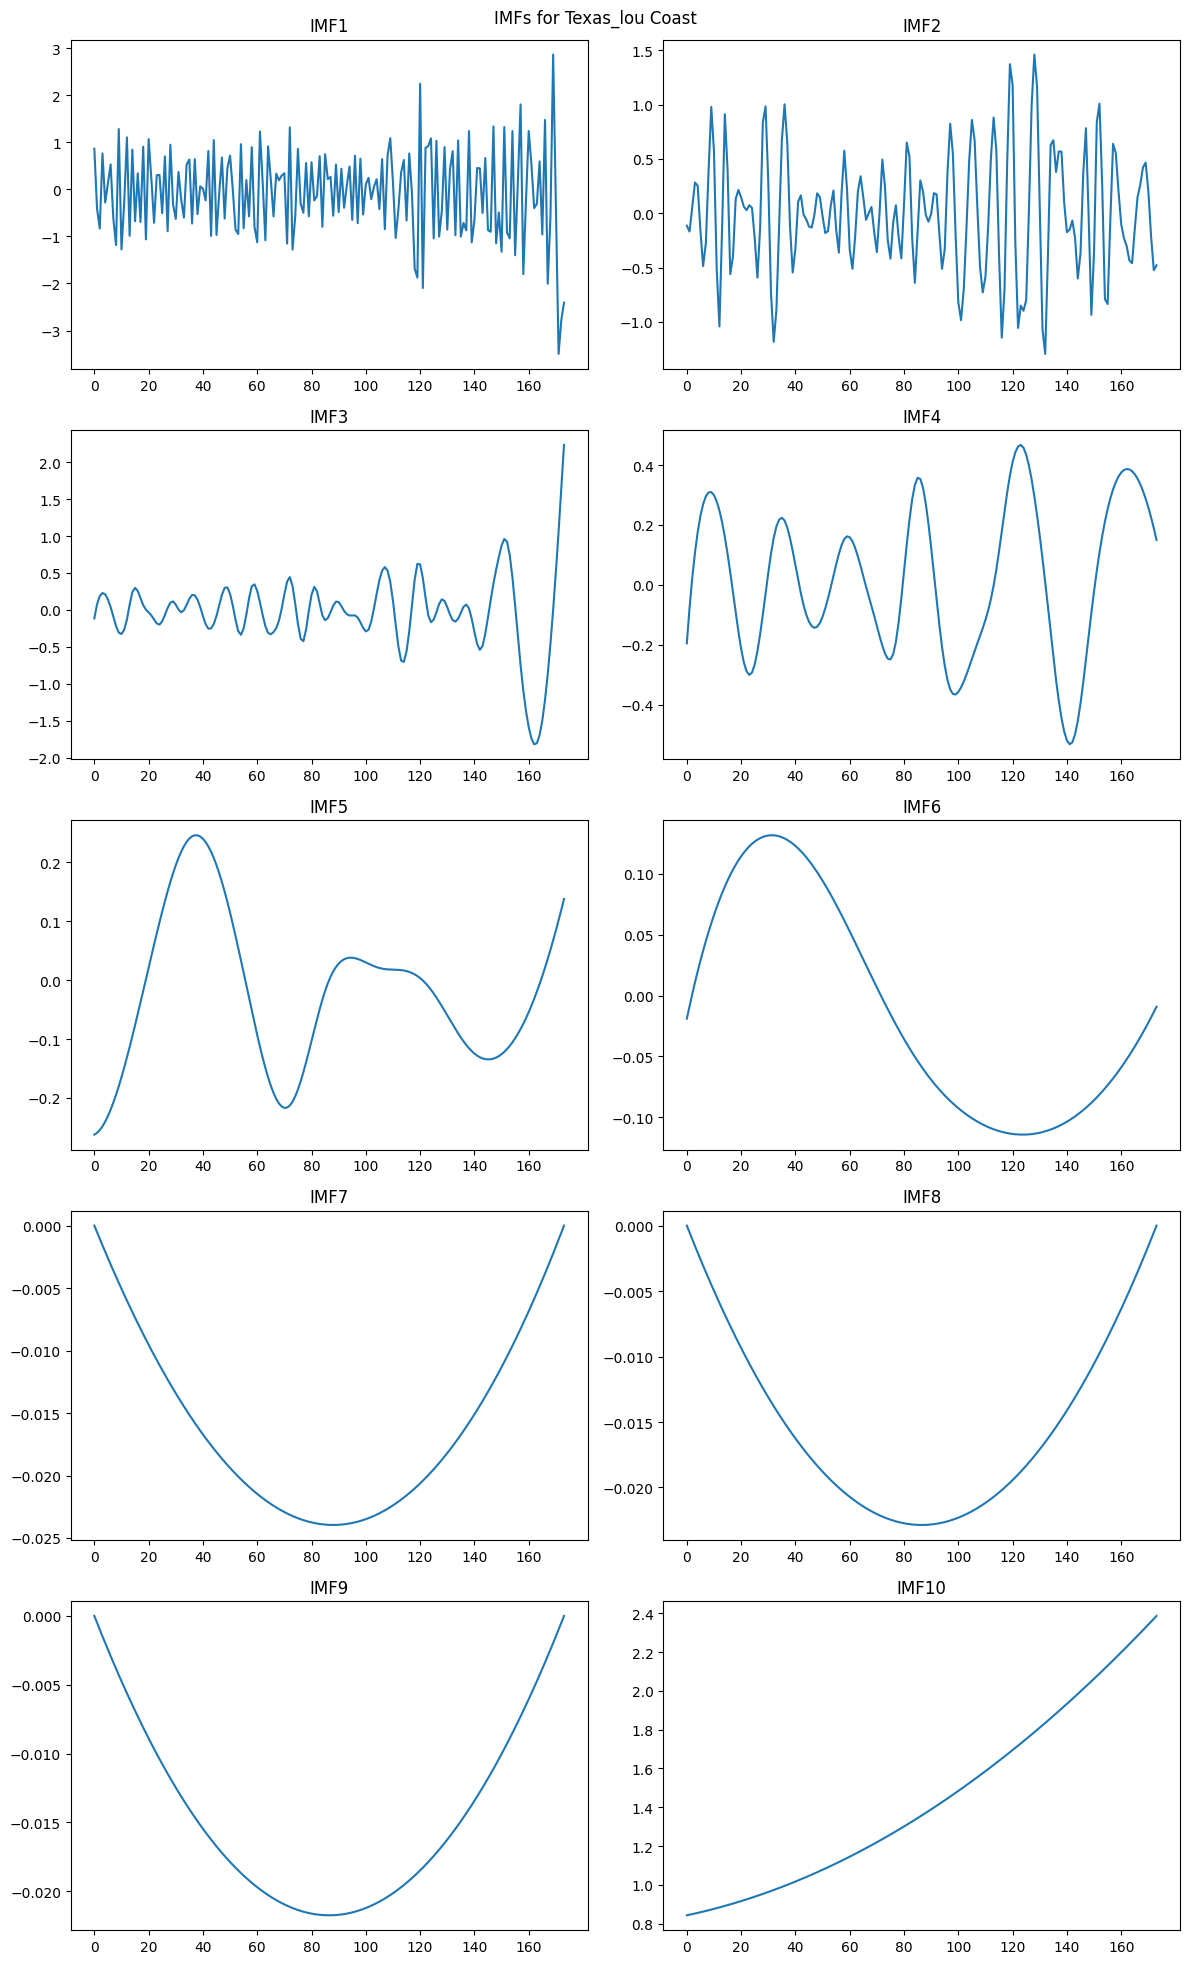

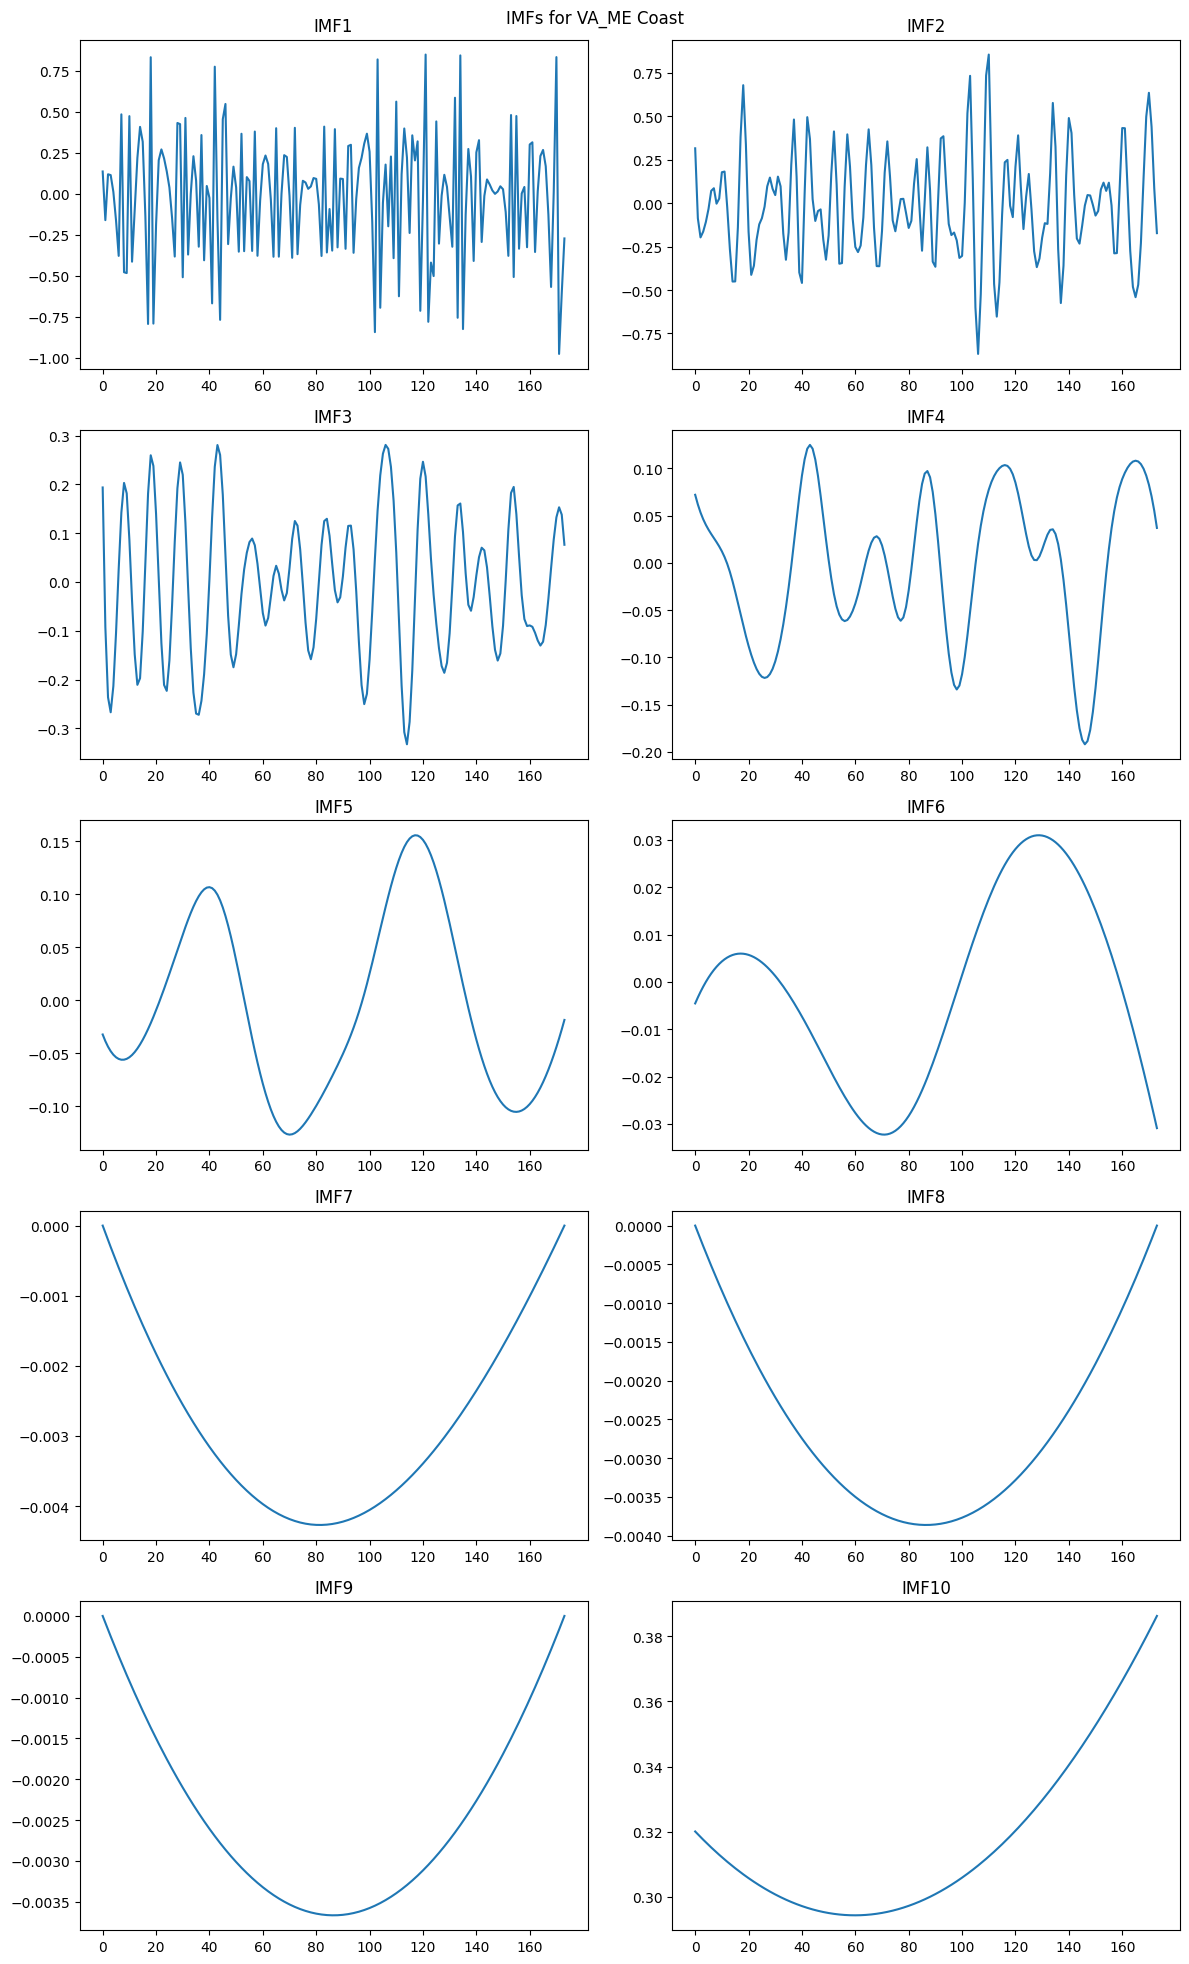

In [31]:
## Making a function to plot IMFs for any coast ##
def plot_imfs(coasts, path, save_fig=False):
    for coast in coasts:
        fig, axes = plt.subplots(nrows=5 , ncols=2, figsize = (12, 20))
        all_imfs_df['t_index'] = all_imfs_df['year'] - all_imfs_df['year'].min() #Creating a time index starting at 0
        # For Loop to iterate through each IMF and plot them
        for i, imf in enumerate(imfs):
            imf_data = all_imfs_df[(all_imfs_df['coast'] == coast) & (all_imfs_df['imf'] == imf)]
            imf_data.plot(x = 't_index', y = 'value', ax = axes.flat[i], legend = False)
            axes.flat[i].set_title(f'IMF{i+1}')
        # Adjusting layout aswell as x an y labels and ticks
            axes.flat[i].set_xlabel("") #Removing x label from each subplot
            axes.flat[i].set_xticks(np.arange(0,175, 20)) #X ticks from 0 to 175 every 20 years
        plt.suptitle(f'IMFs for {coast} Coast')
        plt.tight_layout()
        if save_fig:
            filename = f'IMFs_{coast}.png'
            plt.savefig(os.path.join(path, filename))
# Calling the function for a specific coast
# Function call, with option to save figure, uncomment the save_fig line to save the IMFs. 
# Furthermore, you can specifiy the path to save the figures. Path MUST exist in machine in order to save the figures to the correct location.
# The path variable is only used if save_fig is set to true, but WILL activate whenever save_fig is set to true
plot_imfs(coasts,  
          path = '/Users/epalmer/Meteorology-Research-Dr.-Misra-/Data/IMF_figures/', 
          save_fig=False)